# Basic NN methods for RL

## Part 1. Q-network for Cart-Pole

1. Implement DQN and tune it to ensure stable training (see item 2) within 1000 episodes. You may adjust:
   - epsilon decay and learning rate
   - the number and size of hidden layers in the model
   - replay buffer size and the frequency of replay calls

2. Perform an evaluation over 200 episodes. The goal is to demonstrate that the policy achieves successful stabilization for at least 199 out of 200 episodes.

3. Implement DQN with a Target Network and tune it for stable training within 1000 episodes (see item 4).

4. Perform an evaluation of DQN+Target Network over 200 episodes. The goal is to demonstrate that the policy achieves successful stabilization for at least 199 out of 200 episodes.

In [ ]:
!pip install gymnasium[classic-control] pyvirtualdisplay
!apt-get install -y xvfb python-opengl ffmpeg

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

from IPython import display
from pyvirtualdisplay import Display
d = Display(visible=0, size=(400, 300))
d.start()

import copy
import torch
from torch.autograd import Variable
from torch import nn
import random
import math
import torchvision.transforms as T
import numpy as np
import time
import gymnasium as gym, math

env = gym.make('CartPole-v0')

seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

### DQN with experience replay

In [ ]:
class DQN():
    ''' Deep Q Neural Network class. '''
    def __init__(self, state_dim, action_dim, hidden_dim=16, alpha=0.001):
            self.criterion = nn.MSELoss()
            self.model = nn.Sequential(
                nn.Linear(state_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, action_dim)
            )
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=alpha)

            self.losses = []

    def update(self, state, y):
        """Update the weights of the network given a training sample. """
        y_pred = self.model(torch.Tensor(state))
        loss = self.criterion(y_pred, Variable(torch.Tensor(y)))

        self.losses.append(loss.detach().numpy())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def predict(self, state):
        """ Compute Q values for all actions using the DQL. """
        with torch.no_grad():
            return self.model(torch.Tensor(state))

    def replay(self, size, memory, gamma, tmodel):
      if len(memory) < size:
          return

      batch = random.sample(memory, size)

      batch_t = list(map(list, zip(*batch)))
      states = torch.Tensor(batch_t[0])
      actions = torch.LongTensor(batch_t[1])
      next_states = torch.Tensor(batch_t[2])
      rewards = torch.Tensor(batch_t[3])
      is_done = torch.BoolTensor(batch_t[4])

      is_done_indices = torch.where(is_done==True)[0]

      all_q_values = tmodel.predict(states)
      all_q_values_next = tmodel.predict(next_states)

      all_q_values[range(len(all_q_values)), actions] = rewards + gamma*torch.max(all_q_values_next, axis=1).values

      all_q_values[is_done_indices.tolist(), actions[is_done].tolist()] = rewards[is_done_indices.tolist()]

      self.update(states.tolist(), all_q_values.tolist())


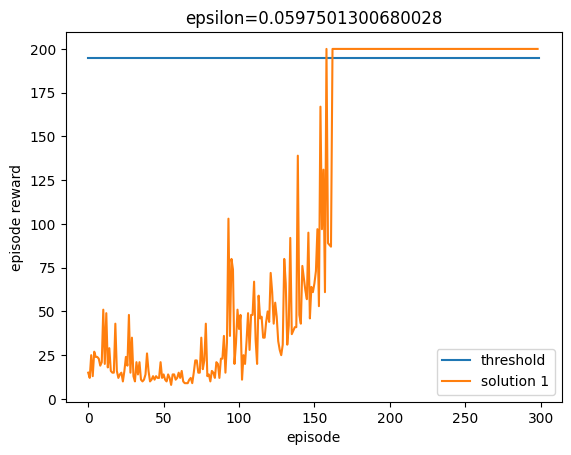

done


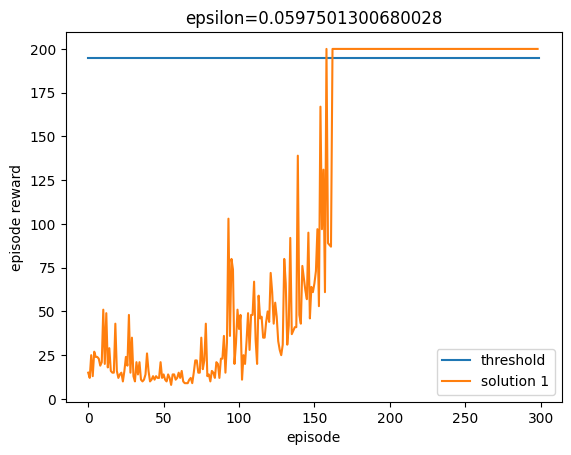

In [ ]:
# Q table
n_states = 4
n_actions = env.action_space.n # Actions

# Learning Parameters
epsilon = 0.9 # gready threashold
epsilon_decay = 0.991
alpha = 3e-4 # learning rate
gamma = 0.99 # reward discount factor

# Execution parameters
SHOW_ANIMATION = False
EPISODES_MAX = 300
STEPS_MAX = 500
DESIRED_STEPS = 200

# Loggers
log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)
log_epsilon = np.zeros(EPISODES_MAX)

#
n_hidden = 32
model = DQN(n_states, n_actions, n_hidden, alpha)

#
memory = []
replay_size = 128

set_seed(seed)

# Q-learning
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    rewards = 0

    log_epsilon[i_episode] = epsilon
    epsilon = epsilon*epsilon_decay

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        # We say that problem is solved, if the mean length of the last 50 episodes it greater then 195
        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('epsilon={}'.format(epsilon))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        q_values = model.predict(state)

        if np.random.random_sample() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation
        memory.append((state, action, next_state, reward, done))

        q_values_list = q_values.tolist()

        model.replay(replay_size, memory, gamma, model)

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        # Update current state
        state = next_state

print("done")

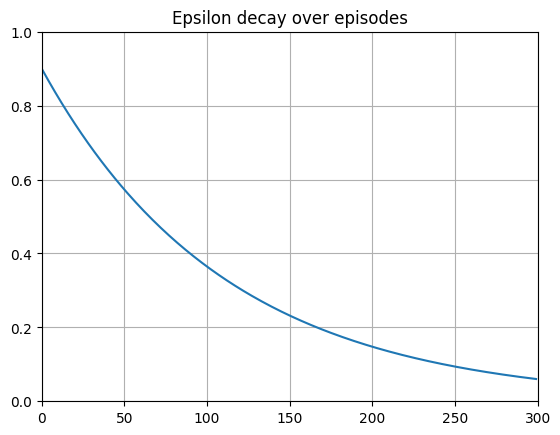

In [ ]:
plt.plot(log_epsilon)
plt.title('Epsilon decay over episodes')
plt.xlim([0, EPISODES_MAX])
plt.ylim([0, 1])
plt.grid()
plt.show()

### Inference

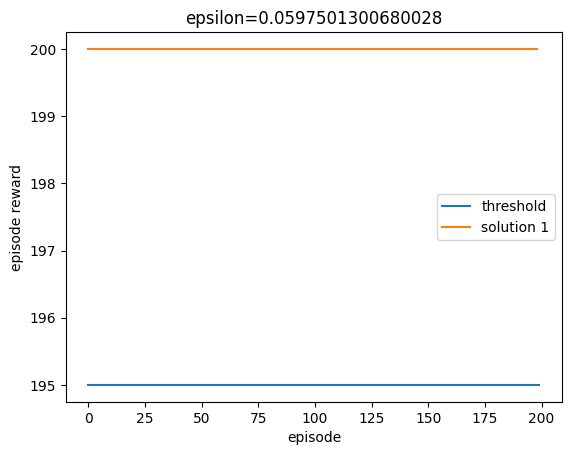

done


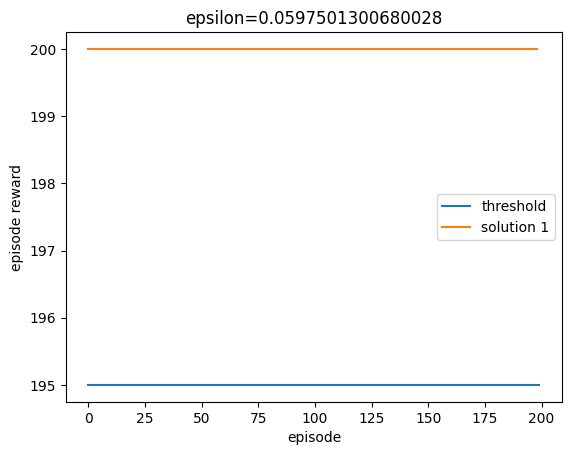

In [ ]:
for i_episode in range(200):
    observation, _ = env.reset()
    rewards = 0
    state = observation

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('epsilon={}'.format(epsilon))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        q_values = model.predict(state)

        action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        state = next_state


print("done")

### DQN with Target Network

In [ ]:
class TargetDQN():
    ''' Deep Q Neural Network class. '''
    def __init__(self, model):
            self.model = model
            self.target_model = copy.deepcopy(model)

    def upgrade(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def predict(self, state):
        """ Compute Q values for all actions using the DQL. """
        with torch.no_grad():
            return self.target_model(torch.Tensor(state))


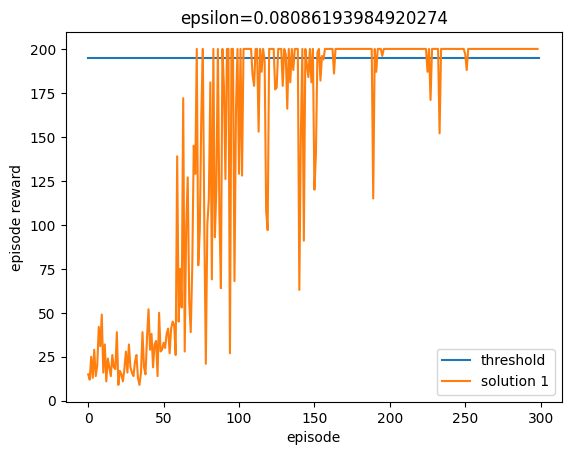

done


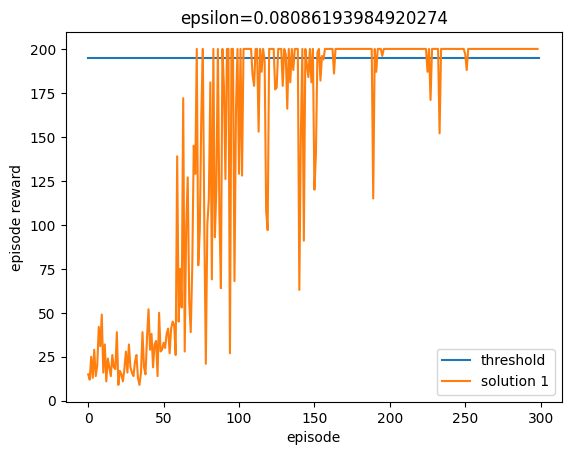

In [ ]:
# Learning Parameters
epsilon = 0.9 # gready threashold
epsilon_decay = 0.992
alpha = 3e-4 # learning rate
gamma = 0.99 # reward discount factor

# Execution parameters
SHOW_ANIMATION = False
EPISODES_MAX = 300
STEPS_MAX = 500
DESIRED_STEPS = 200

# Loggers
log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)
log_epsilon = np.zeros(EPISODES_MAX)

#
n_hidden = 64
model2 = DQN(n_states, n_actions, n_hidden, alpha)
tmodel = TargetDQN(model2.model)

#
memory = []
replay_size = 128
freeze_target_model = 60

set_seed(seed)

# Q-learning
for i_episode in range(EPISODES_MAX):
    observation, _ = env.reset()
    rewards = 0
    state = observation

    log_epsilon[i_episode] = epsilon
    epsilon = epsilon*epsilon_decay

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('epsilon={}'.format(epsilon))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        q_values = model2.predict(state)

        if np.random.random_sample() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation
        memory.append((state, action, next_state, reward, done))

        q_values_list = q_values.tolist()

        model2.replay(replay_size, memory, gamma, tmodel)
        freeze_target_model -= 1

        if freeze_target_model == 0:
            tmodel.upgrade()
            freeze_target_model = 60

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        # Update current state
        state = next_state

print("done")

### Inference

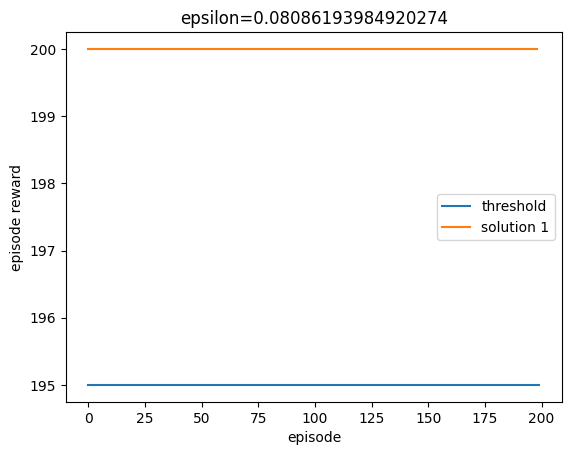

done


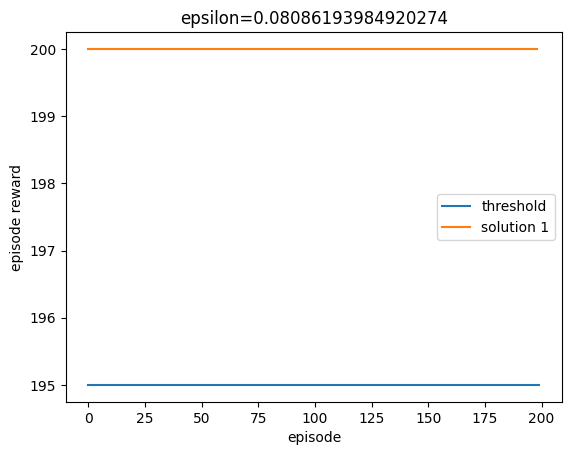

In [ ]:
EPISODES_MAX = 200

for i_episode in range(EPISODES_MAX):
    observation, _ = env.reset()
    rewards = 0
    state = observation

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('epsilon={}'.format(epsilon))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        q_values = model2.predict(state)

        action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        # Update current state
        state = next_state


print("done")

## Часть 2. Simple Policy Gradient implementation

1. Implement [Simple PG](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html) and tune it to have stable learning under 2000 episodes. At least try to change
- epsilon decay
- number and a size of the hidden layers in the model
- learning rate
- batch size

2. Implement Reward-To-Go

In [ ]:
class PG():
    def __init__(self, state_dim, action_dim, hidden_dim=12, alpha=0.001):
        self.model = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=alpha)
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(self.optimizer, gamma=0.99)

    def get_policy(self, obs):
        state = torch.FloatTensor(obs)
        logits = self.model(state)
        return torch.distributions.Categorical(logits=logits)

    def get_action(self, obs):
        return self.get_policy(obs).sample().item()

    def update(self, batch_states, batch_actions, batch_weights):
        self.optimizer.zero_grad()

        obs = torch.as_tensor(batch_states, dtype=torch.float32)
        act = torch.as_tensor(batch_actions, dtype=torch.int32)
        weights = torch.as_tensor(batch_weights, dtype=torch.float32)

        logp = self.get_policy(obs).log_prob(act)
        loss = -(logp * weights).mean()

        loss.backward()
        self.optimizer.step()

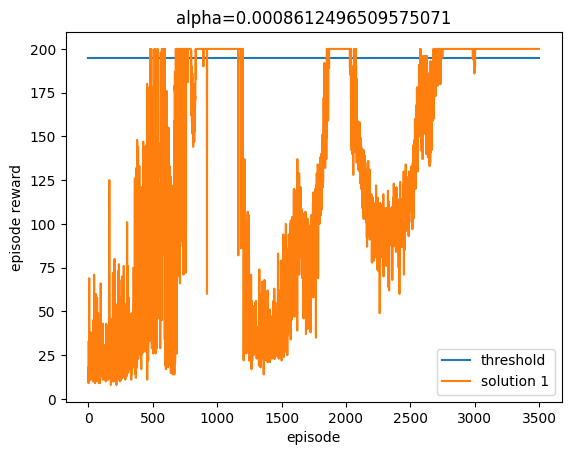

Early stopping triggered at episode 3503
Average reward over last 500 episodes: 200.00
done


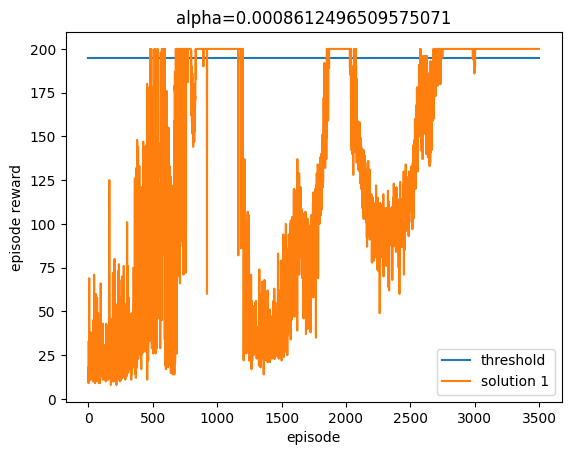

In [ ]:
set_seed(seed)

pg_alpha = 0.005
pg_n_hidden = 64
model_pg = PG(n_states, n_actions, pg_n_hidden, pg_alpha)

EPISODES_MAX = 4000
STEPS_MAX = 500

log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)

#
batch_size = 500

batch_states = []
batch_actions = []
batch_weights = []

episode_states = []
episode_actions = []
episode_rewards = []

early_stop_threshold = 200
window_size = 500
early_stop_achieved = False

for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()

    rewards = 0
    episode_states = []
    episode_actions = []
    episode_rewards = []

    if (i_episode + 1) % 20 == 0:
        model_pg.scheduler.step()

    if (i_episode + 1) % 100 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('alpha={}'.format(model_pg.scheduler.get_last_lr()[0]))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state) 
        observation, reward, truncated, terminated, info = env.step(action)
        done = truncated or terminated

        rewards += reward
        next_state = observation

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        state = next_state

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t

            ep_return, ep_len = sum(episode_rewards), len(episode_rewards)

            batch_states += episode_states
            batch_actions += episode_actions
            batch_weights += [ep_return] * ep_len

            # Update policy
            if len(batch_states) >= batch_size:
                model_pg.update(batch_states, batch_actions, batch_weights)
                batch_states = []
                batch_actions = []
                batch_weights = []
            break

    # Добавим остановку обучения при достижении оптимальной политики (среднее общее вознаграждение за 100 эпизодов = 200)
    if i_episode >= window_size:
        moving_average = np.mean(log_total_reward[i_episode-window_size+1:i_episode+1])
        if moving_average >= early_stop_threshold:
            print(f"Early stopping triggered at episode {i_episode+1}")
            print(f"Average reward over last {window_size} episodes: {moving_average:.2f}")
            early_stop_achieved = True
            break


print("done")

In general, we could have stopped at around 1000 episodes, but during inference it was observed that the agent occasionally performed very poorly on the task. Therefore, we decided to increase the window for calculating the average reward to 500. Now, even at 2000 episodes, the task is successfully solved during inference.

### Inference

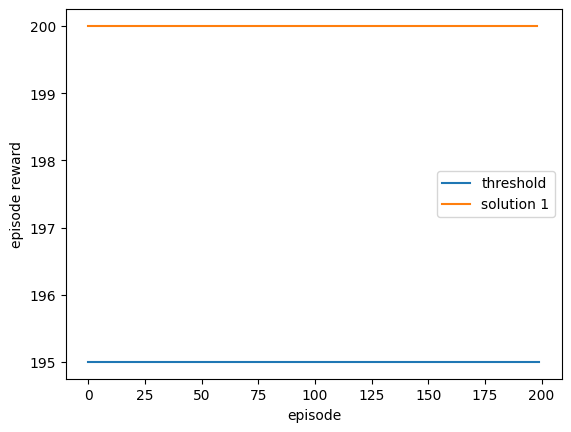

done


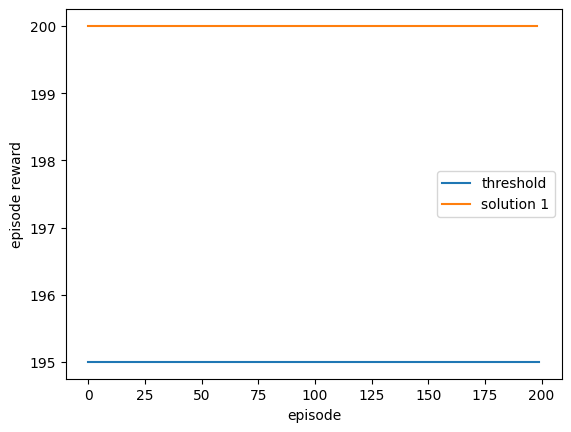

In [ ]:
EPISODES_MAX = 200

for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()

    rewards = 0
    episode_states = []
    episode_actions = []
    episode_rewards = []

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state)
        observation, reward, truncated, terminated, info = env.step(action)
        done = truncated or terminated

        rewards += reward
        next_state = observation

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        state = next_state

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

print("done")

### Reward-To-Go


In [ ]:
def reward_to_go(rews):
    n = len(rews)
    rtgs = np.zeros_like(rews)
    for i in reversed(range(n)):
        rtgs[i] = rews[i] + (rtgs[i+1] if i+1 < n else 0)
    return rtgs

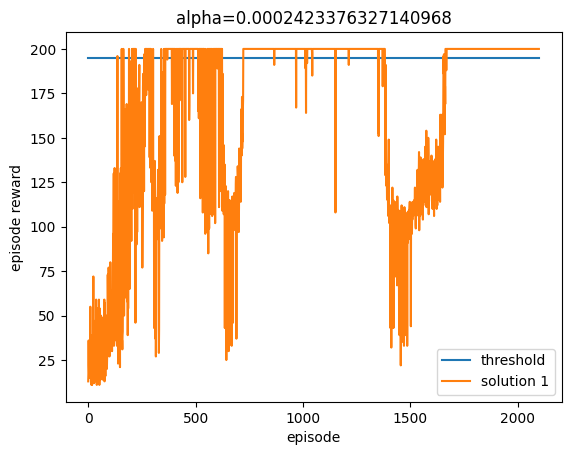

Early stopping triggered at episode 2168
Average reward over last 500 episodes: 200.00
done


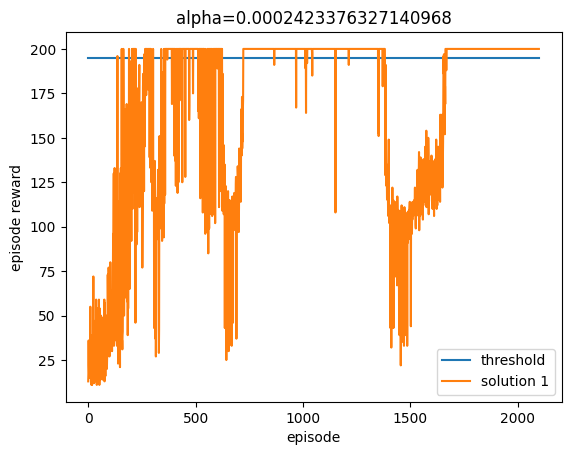

In [ ]:
set_seed(seed)

pg_alpha = 0.002
pg_n_hidden = 256
model_pg = PG(n_states, n_actions, pg_n_hidden, pg_alpha)

EPISODES_MAX = 5000
STEPS_MAX = 500

log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)

#
batch_size = 2**9

batch_states = []
batch_actions = []
batch_weights = []

episode_states = []
episode_actions = []
episode_rewards = []

early_stop_threshold = 200
window_size = 500
early_stop_achieved = False

for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()

    rewards = 0
    episode_states = []
    episode_actions = []
    episode_rewards = []

    if (i_episode + 1) % 10 == 0:
        model_pg.scheduler.step()

    if (i_episode + 1) % 100 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('alpha={}'.format(model_pg.scheduler.get_last_lr()[0]))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state)
        observation, reward, truncated, terminated, info = env.step(action)
        done = truncated or terminated

        rewards += reward
        next_state = observation

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        state = next_state

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t

            ep_return, ep_len = sum(episode_rewards), len(episode_rewards)

            batch_states += episode_states
            batch_actions += episode_actions
            batch_weights += list(reward_to_go(episode_rewards)) # Изменили эту строчку

            # Update policy
            if len(batch_states) >= batch_size:
                model_pg.update(batch_states, batch_actions, batch_weights)
                batch_states = []
                batch_actions = []
                batch_weights = []
            break

    # Add early stopping when the optimal policy is achieved (mean total reward over 100 episodes = 200).
    if i_episode >= window_size:
        moving_average = np.mean(log_total_reward[i_episode-window_size+1:i_episode+1])
        if moving_average >= early_stop_threshold:
            print(f"Early stopping triggered at episode {i_episode+1}")
            print(f"Average reward over last {window_size} episodes: {moving_average:.2f}")
            early_stop_achieved = True
            break


print("done")

### Inference

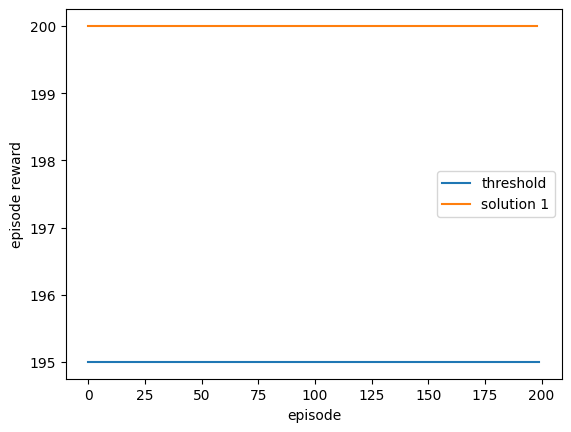

done


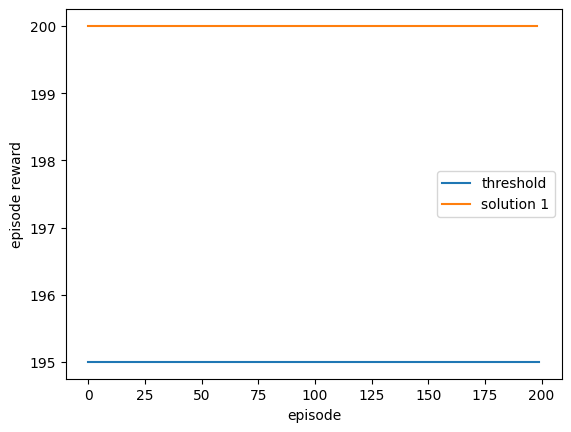

In [ ]:
EPISODES_MAX = 200

for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()

    rewards = 0
    episode_states = []
    episode_actions = []
    episode_rewards = []

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [195, 195], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model_pg.get_action(state)
        observation, reward, truncated, terminated, info = env.step(action)
        done = truncated or terminated

        rewards += reward
        next_state = observation

        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        state = next_state

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

print("done")